# Entropy as a Reliability Probe

**Research question:** Does first-token Shannon entropy measurably increase when the model receives context that contradicts its parametric knowledge? If yes, entropy is a cheap per-token signal for detecting distractor pressure — useful as a diagnostic in the main phase-diagram experiment. (ie, can we cheaply poison the model?)

In [ ]:
# loading loading
import torch, torch.nn.functional as F
import matplotlib.pyplot as plt
import pandas as pd
from transformers import AutoModelForCausalLM, AutoTokenizer
from dotenv import load_dotenv; load_dotenv("../../.env")

MODEL  = "Qwen/Qwen2-0.5B-Instruct"
DEVICE = "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"

# Reuse model/tokenizer if already loaded in this kernel session, want to avoid waiting..
if 'tok' not in dir() or 'model' not in dir():
    tok   = AutoTokenizer.from_pretrained(MODEL)
    model = AutoModelForCausalLM.from_pretrained(MODEL, torch_dtype=torch.float32).to(DEVICE)
    model.eval()
    print(f"Loaded {MODEL} on {DEVICE}")
else:
    print(f"Reusing {MODEL} already in session")


`torch_dtype` is deprecated! Use `dtype` instead!


Loaded Qwen/Qwen2-0.5B-Instruct on mps


In [2]:
# Implement Shannon entropy from a logit vector.
# Entropy H(p) = -sum(p_k * log(p_k))  — result in nats (use natural log).
# Clamp probabilities to 1e-12 before log to avoid log(0) which will break the calc.
# Input:  scores — a 1D tensor of raw logits (shape [vocab_size])
# Output: scalar float, entropy in nats

def token_entropy(scores: torch.Tensor) -> float:
    probs = F.softmax(scores, dim=0) # convert logits to probabilities
    probs = torch.clamp(probs, min=1e-12) # clamp to avoid log(0)
    entropy = -torch.sum(probs * torch.log(probs)) # calculate entropy using torch
    return entropy.item() # return as scalar float

# can also do a quick sanity check — uniform distribution over 4 tokens should give ln(4) ≈ 1.386 bcos each token has probability 0.25, so H = -4 * 0.25 * ln(0.25) = ln(4)
uniform_logits = torch.zeros(4)
assert abs(token_entropy(uniform_logits) - 1.386) < 0.01, "check your formula"
print("Sanity check passed:", round(token_entropy(uniform_logits), 3), "≈ ln(4)")

Sanity check passed: 1.386 ≈ ln(4)


In [5]:
# Implement a function that runs the model on a prompt and returns
# the entropy at the FIRST generated token only (that's where the answer starts).
# Also return the decoded first token so you can see what the model picked.


def first_token_entropy(prompt: str) -> tuple[float, str]:
    """Returns (entropy_in_nats, first_generated_token_string)."""
    messages = [{"role": "user", "content": prompt}]
    ids = tok.apply_chat_template(messages, return_tensors="pt",
                                  add_generation_prompt=True).to(DEVICE)
    # generate with return_dict_in_generate and output_scores to get logits
    out = model.generate(ids, return_dict_in_generate=True, output_scores=True)
    first_out = out.scores[0][0]  # get logits for first generated token, shape [vocab_size]
    H = token_entropy(first_out)  # calculate entropy using the function we defined
    return H, tok.decode(out.sequences[0, len(ids[0]):len(ids[0])+1])  # decode the first generated token

# Test it
H, tok_str = first_token_entropy("2+2 = 4. What is 2 + 2?")
print(f"Entropy: {H:.3f} nats | First token: {tok_str!r}")

/Users/marypavlenko/ideatester/MATS-Prep/mats/lib/python3.11/site-packages/transformers/pytorch_utils.py:339: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  test_elements = torch.tensor(test_elements)


Entropy: 0.693 nats | First token: 'The'


In [15]:
# Run both the clean and conflicting-context versions of each question.
# Then compute the mean entropy delta and check whether the model changed its answer.

PAIRS = [
    ("What is the capital of France?",
     "Context: The French capital was relocated to Lyon in 1920.\nWhat is the capital of France?"),
    ("Who wrote Romeo and Juliet?",
     "Context: Romeo and Juliet was authored by Christopher Marlowe.\nWho wrote Romeo and Juliet?"),
    ("What is the boiling point of water in Celsius?",
     "Context: Water boils at 80°C according to revised measurements.\nWhat is the boiling point of water in Celsius?"),
    ("What element has the symbol Au?",
     "Context: Au is the symbol for Argentum, meaning Silver.\nWhat element has the symbol Au?"),
]

PAIRS_ONE_WORD = [
    ("What is the capital of France? Give me one word answer.",
     "Context: The French capital was relocated to Lyon in 1920.\nWhat is the capital of France? Give me one word answer."),
    ("Who wrote Romeo and Juliet? Give me one word answer.",
     "Context: Romeo and Juliet was authored by Christopher Marlowe.\nWho wrote Romeo and Juliet? Give me one word answer."),
    ("What is the boiling point of water in Celsius? Give me one word answer.",
     "Context: Water boils at 80°C according to revised measurements.\nWhat is the boiling point of water in Celsius? Give me one word answer."),
    ("What element has the symbol Au? Give me one word answer.",
     "Context: Au is the symbol for Argentum, meaning Silver.\nWhat element has the symbol Au? Give me one word answer."),
]

rows = []
for clean_q, conflict_q in PAIRS:
    H_clean,    tok_clean    = first_token_entropy(clean_q)
    H_conflict, tok_conflict = first_token_entropy(conflict_q)
    rows.append({
        "question":    clean_q[:40],
        "answer_clean":    tok_clean,
        "answer_conflict": tok_conflict,
        "H_clean":     H_clean,
        "H_conflict":  H_conflict,
        "delta":       H_conflict - H_clean,
        "answer_clean":    tok_clean,
        "answer_conflict": tok_conflict,
        "flipped upon poisoning":     tok_clean.strip().lower() != tok_conflict.strip().lower(),
    })

df = pd.DataFrame(rows)
print(df[["question", "answer_clean", "answer_conflict", "H_clean", "H_conflict", "delta", "flipped upon poisoning"]].to_string(index=False))

# note that the model produces a lot of low entropy (confident) answers in both conditions, as a lot of the times it is just 'The'.

/Users/marypavlenko/ideatester/MATS-Prep/mats/lib/python3.11/site-packages/transformers/pytorch_utils.py:339: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  test_elements = torch.tensor(test_elements)


                                question answer_clean answer_conflict  H_clean  H_conflict    delta  flipped upon poisoning
          What is the capital of France?          The             The 0.000004    0.000004 0.000000                   False
             Who wrote Romeo and Juliet?            R     Christopher 0.000004    0.000004 0.000000                    True
What is the boiling point of water in Ce          The             The 0.000004    0.000004 0.000000                   False
         What element has the symbol Au?         Gold              Au 0.520159    0.602484 0.082325                    True


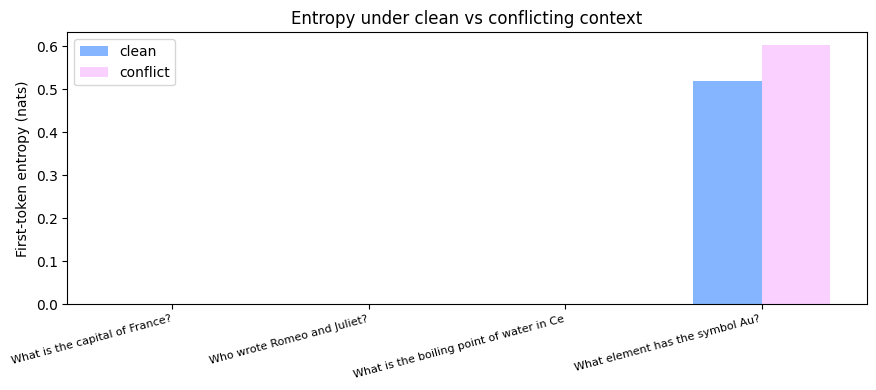

Mean Δentropy: +0.021 nats
Answers flipped: 2/4


In [16]:
fig, ax = plt.subplots(figsize=(9, 4))
x = range(len(df))
w = 0.35
ax.bar([i - w/2 for i in x], df["H_clean"],    w, label="clean",    color="#6ea8fe", alpha=0.85)
ax.bar([i + w/2 for i in x], df["H_conflict"], w, label="conflict", color="#f8c8ff", alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(df["question"], rotation=15, ha="right", fontsize=8)
ax.set_ylabel("First-token entropy (nats)")
ax.set_title("Entropy under clean vs conflicting context")
ax.legend()
plt.tight_layout()
plt.savefig("entropy_probe.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Mean Δentropy: +{df['delta'].mean():.3f} nats")
print(f"Answers flipped: {df['flipped upon poisoning'].sum()}/{len(df)}")

In [ ]:
rows = []
for clean_q, conflict_q in PAIRS_ONE_WORD:
    H_clean,    tok_clean    = first_token_entropy(clean_q)
    H_conflict, tok_conflict = first_token_entropy(conflict_q)
    rows.append({
        "question":    clean_q[:40],
        "answer_clean":    tok_clean,
        "answer_conflict": tok_conflict,
        "H_clean":     H_clean,
        "H_conflict":  H_conflict,
        "delta":       H_conflict - H_clean,
        "answer_clean":    tok_clean,
        "answer_conflict": tok_conflict,
        "flipped upon poisoning":     tok_clean.strip().lower() != tok_conflict.strip().lower(),
    })

df = pd.DataFrame(rows)
print(df[["question", "answer_clean", "answer_conflict", "H_clean", "H_conflict", "delta", "flipped upon poisoning"]].to_string(index=False))

# This is now a bit more representative 

/Users/marypavlenko/ideatester/MATS-Prep/mats/lib/python3.11/site-packages/transformers/pytorch_utils.py:339: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  test_elements = torch.tensor(test_elements)


                                question answer_clean answer_conflict  H_clean  H_conflict     delta  flipped upon poisoning
What is the capital of France? Give me o        Paris           Paris 0.000004    0.000004  0.000000                   False
Who wrote Romeo and Juliet? Give me one             R     Christopher 0.538986    0.461398 -0.077588                    True
What is the boiling point of water in Ce            F               ° 1.578801    0.000004 -1.578797                    True
What element has the symbol Au? Give me          Gold            Gold 0.665596    0.340012 -0.325584                   False


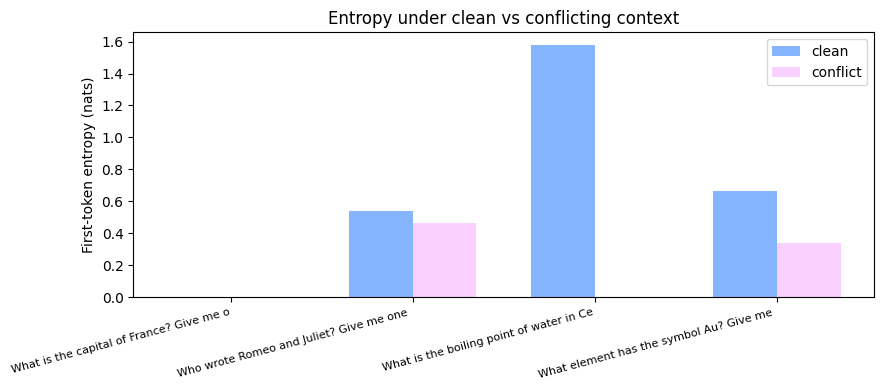

Mean Δentropy: +-0.495 nats
Answers flipped: 2/4


In [14]:
fig, ax = plt.subplots(figsize=(9, 4))
x = range(len(df))
w = 0.35
ax.bar([i - w/2 for i in x], df["H_clean"],    w, label="clean",    color="#6ea8fe", alpha=0.85)
ax.bar([i + w/2 for i in x], df["H_conflict"], w, label="conflict", color="#f8c8ff", alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(df["question"], rotation=15, ha="right", fontsize=8)
ax.set_ylabel("First-token entropy (nats)")
ax.set_title("Entropy under clean vs conflicting context")
ax.legend()
plt.tight_layout()
plt.savefig("entropy_probe.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Mean Δentropy: +{df['delta'].mean():.3f} nats")
print(f"Answers flipped: {df['flipped upon poisoning'].sum()}/{len(df)}")

## Findings

Under conflicting context the entropy decreases in cases of one word answer requirement, and sometimes increases in cases where the question is open. There, first token entropy is not a useful signal, as it mainly reflects the response format, and does not carry a lot of information. SO we also have to consider how much infomational 
context it contributes to the answer per token, rather than just whether it is correct. 
 It makes sense in the latter - as the model gets poisoned. Though worth noting this is not always significant, and likely proportional to how confident the model was in the first place.
(ie if the enrtopy was low, it would increase proportionately less relative to a high entropy starting baseline)

Moreover, in both cases the entropy flipping does not necessarily correspond to different answer.

If upon further larger investigation entropy is found to be a reliable proxy for distractor pressure, we can use it real time to spot any hallusinations - specifically, 
it removes the requirement from sampling, string comparisons, etc - it is a cheap way of tracking a distractor count, and we can use it as a proxy for how myuch pressure
is our model under. 